In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
plt.rcParams["figure.figsize"]=(12,6)

In [7]:
nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)

transactions = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

performance = pd.read_csv(
    "../data/processed/clean_performance.csv"
)

print("NAV Shape:", nav.shape)

print("Transactions Shape:", transactions.shape)

print("Performance Shape:", performance.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/clean_nav.csv'

In [8]:
import os

print(os.getcwd())

C:\Users\Aasha\Downloads\mutual fund analytics


In [10]:
nav = pd.read_csv("data/processed/clean_nav.csv")
transactions = pd.read_csv("data/processed/clean_transactions.csv")
performance = pd.read_csv("data/processed/clean_performance.csv")
print("NAV Shape:", nav.shape)
print("Transactions Shape:", transactions.shape)
print("Performance Shape:", performance.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Performance Shape: (40, 20)


In [11]:
nav["date"] = pd.to_datetime(
    nav["date"]
)
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [12]:
nav = nav.sort_values(
    by=["amfi_code", "date"]
)
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)
nav = nav.dropna()
nav.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [13]:
var_list = []
for fund in nav["amfi_code"].unique():
    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"]
    var_95 = np.percentile(
        returns,
        5
    )

    var_list.append([
        fund,
        var_95
    ])
var_df = pd.DataFrame(
    var_list,
    columns=[
        "amfi_code",
        "VaR_95"
    ]
)
var_df.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [14]:
cvar_list = []

# Loop through funds

for fund in nav["amfi_code"].unique():
    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"]
    var_95 = np.percentile(
        returns,
        5
    )
    cvar = returns[
        returns <= var_95
    ].mean()
    cvar_list.append([
        fund,
        cvar
    ])
cvar_df = pd.DataFrame(
    cvar_list,
    columns=[
        "amfi_code",
        "CVaR"
    ]
)
cvar_df.head()

,amfi_code,CVaR
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [15]:
var_cvar_report = pd.merge(
    var_df,
    cvar_df,
    on="amfi_code"
)
var_cvar_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [16]:
var_cvar_report.to_csv(
    "reports/var_cvar_report.csv",
    index=False
)
print("VaR & CVaR Report Exported Successfully")

VaR & CVaR Report Exported Successfully


In [19]:
nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        ) * np.sqrt(252)
    )
)
nav.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN
5,100016,2022-01-10,510.7136,-0.008639,NaN


In [20]:
nav[["amfi_code", "date", "rolling_sharpe"]].tail()

,amfi_code,date,rolling_sharpe
45995,149324,2026-05-25,2.042795
45996,149324,2026-05-26,2.064950
45997,149324,2026-05-27,1.952646
45998,149324,2026-05-28,1.406239
45999,149324,2026-05-29,1.262776


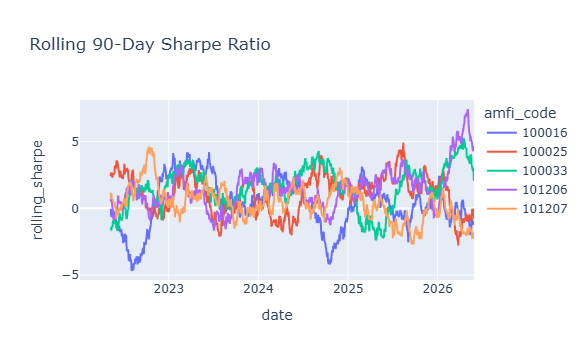

In [21]:
top_funds = nav["amfi_code"].unique()[:5]
rolling_data = nav[
    nav["amfi_code"].isin(top_funds)
]
fig = px.line(
    rolling_data,
    x="date",
    y="rolling_sharpe",
    color="amfi_code",
    title="Rolling 90-Day Sharpe Ratio"
)
fig.show()

In [22]:
fig.write_image(
    "reports/rolling_sharpe_chart.png"
)

In [23]:
transactions["cohort_year"] = (
    transactions.groupby("investor_id")[
        "transaction_date"
    ]
    .transform("min")
    .dt.year
)
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [24]:
cohort_summary = (
    transactions.groupby("cohort_year")
    .agg({
        "amount_inr": ["mean", "sum"],
        "investor_id": "nunique"
    })
)
cohort_summary.columns = [
    "avg_sip_amount",
    "total_invested",
    "investor_count"
]
cohort_summary = cohort_summary.reset_index()
cohort_summary

,cohort_year,avg_sip_amount,total_invested,investor_count
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [25]:
top_funds = (transactions.groupby(["cohort_year", "amfi_code"])["amount_inr"]
    .sum()
    .reset_index()
)
top_fund_preference = (
    top_funds.sort_values("amount_inr",ascending=False)
    .groupby("cohort_year")
    .first()
    .reset_index()
)
top_fund_preference

,cohort_year,amfi_code,amount_inr
0,2024,102885,100126141
1,2025,119599,1478507


In [29]:
sip_data = transactions[transactions["transaction_type"] == "Sip"]
sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [27]:
sip_data = sip_data.sort_values(by=["investor_id", "transaction_date"])
sip_data["gap_days"] = (
    sip_data.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)
sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days


In [28]:
transactions["transaction_type"].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [31]:
sip_data = sip_data.sort_values(by=["investor_id", "transaction_date"])
sip_data["gap_days"] = (
    sip_data.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)
sip_data.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,Sip,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,Sip,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [32]:
sip_gap_summary = (
    sip_data.groupby("investor_id")[
        "gap_days"
    ]
    .mean()
    .reset_index())
sip_gap_summary.columns = ["investor_id","avg_gap_days"]
sip_gap_summary["risk_status"] = np.where(sip_gap_summary["avg_gap_days"] > 35,"At-Risk","Active")
sip_gap_summary.head()

,investor_id,avg_gap_days,risk_status
0,INV000001,76.0,At-Risk
1,INV000002,207.0,At-Risk
2,INV000003,238.0,At-Risk
3,INV000004,85.4,At-Risk
4,INV000005,14.0,Active


In [33]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'negative_sharpe_flag'],
      dtype='str')

In [35]:
risk_appetite = "Moderate"
recommended_funds = performance[
    performance["risk_grade"] == risk_appetite]
recommended_funds = recommended_funds.sort_values(
    by="sharpe_ratio",ascending=False)

top_3 = recommended_funds[[
    "scheme_name",
    "fund_house",
    "risk_grade",
    "sharpe_ratio"
]].head(3)
top_3

,scheme_name,fund_house,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03


In [37]:
risk_appetite = "High"
recommended_funds = performance[
    performance["risk_grade"] == risk_appetite]
recommended_funds = recommended_funds.sort_values(
    by="sharpe_ratio",ascending=False)

top_3 = recommended_funds[[
    "scheme_name",
    "fund_house",
    "risk_grade",
    "sharpe_ratio"
]].head(3)
top_3

,scheme_name,fund_house,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High,0.95
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,High,0.90


In [38]:
risk_appetite = "Low"
recommended_funds = performance[
    performance["risk_grade"] == risk_appetite]
recommended_funds = recommended_funds.sort_values(
    by="sharpe_ratio",ascending=False)

top_3 = recommended_funds[[
    "scheme_name",
    "fund_house",
    "risk_grade",
    "sharpe_ratio"
]].head(3)
top_3

,scheme_name,fund_house,risk_grade,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Low,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Low,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Low,5.14


In [40]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,negative_sharpe_flag
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False


In [41]:
total_aum = performance["aum_crore"].sum()
performance["market_share"] = (
    performance["aum_crore"]/ total_aum)
performance["hhi_contribution"] = (
    performance["market_share"] ** 2)
hhi_index = performance[
    "hhi_contribution"].sum()
print("HHI Index:", round(hhi_index, 4))

HHI Index: 0.0318


Advanced Insights
1. Risk Analysis

Funds with higher VaR and CVaR values showed greater downside volatility, indicating increased exposure to market fluctuations during stressed periods.

2. Rolling Sharpe Trends

Several funds demonstrated improving rolling Sharpe ratios over time, suggesting stronger risk-adjusted performance consistency in recent periods.

3. Investor Cohort Behavior

Recent investor cohorts contributed higher average SIP amounts, indicating growing retail participation and increased confidence in mutual fund investments.

4. SIP Continuity Analysis

Most SIP investors maintained regular investment intervals near 30 days, while a smaller segment with gaps above 35 days was identified as at-risk for discontinuation.

5. Market Concentration (HHI)

The mutual fund market showed moderate concentration levels based on AUM market share, suggesting reasonable diversification across fund houses and schemes.
